In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving S&P Lima General Historical Data.csv to S&P Lima General Historical Data (3).csv


In [ ]:
# ==============================================================================
# 1. CARGA Y LIMPIEZA QUIRÚRGICA
# ==============================================================================
file_name = 'S&P Lima General Historical Data.csv'

# Cargar
df_raw = pd.read_csv(file_name)

# --- CORRECCIÓN CLAVE: SELECCIÓN DE COLUMNAS ---
# Nos quedamos SOLO con lo que necesitamos. Eliminamos 'Vol.', 'Change %', etc.
df = df_raw[['Date', 'Price']].copy()

# Limpieza de Precio
if df['Price'].dtype == object:
    df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)

# Limpieza de Fechas (Formato EEUU)
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y", errors='coerce')

# Ordenar
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

# Calcular Retornos
df['log_ret'] = np.log(df['Price']).diff()

# Eliminar solo filas donde falte el RETORNO o la FECHA (Blindado)
df.dropna(subset=['log_ret', 'Date'], inplace=True)

print(f"✅ Datos limpios: {len(df)} registros.")

✅ Datos limpios: 4238 registros.


In [ ]:
# ==============================================================================
# 2. INGENIERÍA DE CARACTERÍSTICAS (LAGS)
# ==============================================================================
# Ahora df solo tiene [Date, Price, log_ret]. El dropna() ya no fallará.

def create_lags(data, lags=21):
    d = data.copy()
    for i in range(1, lags + 1):
        d[f'lag_{i}'] = d['log_ret'].shift(i)
    # Esto ahora solo borra los primeros 10 días (no todo el dataset)
    d.dropna(inplace=True)
    return d

LAGS = 21  # Mirar 10 días atrás
df_ml = create_lags(df, lags=LAGS)

# Separar X e y
# X = Todos los lags
# y = log_ret (el de hoy)
features = [c for c in df_ml.columns if 'lag_' in c]
X = df_ml[features].values
y = df_ml['log_ret'].values
fechas = df_ml['Date'].values

print(f"✅ Matriz X generada: {X.shape} (Filas, Lags)")

✅ Matriz X generada: (4217, 21) (Filas, Lags)


Train: 3369 | Test: 848
🌲 Entrenando modelo...

📊 RESULTADOS FINALES (Sobre el Precio del Índice):
----------------------------------------
RMSE: S/. 6552.51
MAE:  S/. 5725.22
MAPE: 22.66% (Este sí es el error promedio real)
----------------------------------------


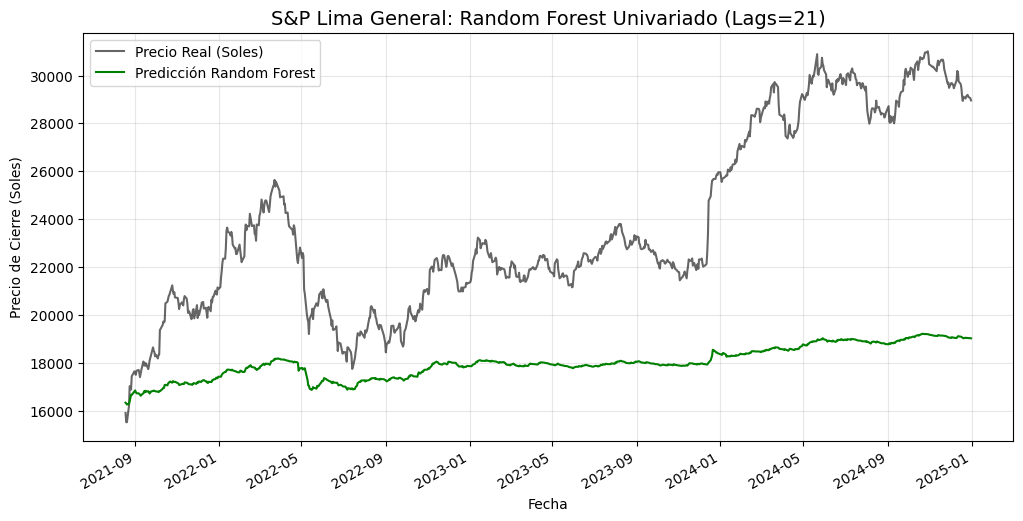

In [ ]:
# ==============================================================================
# 3. SPLIT Y ENTRENAMIENTO
# ==============================================================================
# Usamos df_ml para asegurar alineación
precio_real_total = df_ml['Price'].values # Guardamos precios reales alineados

if len(X) > 0:
    fecha_corte = pd.Timestamp('2021-08-18')
    mask_train = fechas < fecha_corte

    X_train, y_train = X[mask_train], y[mask_train]
    X_test, y_test = X[~mask_train], y[~mask_train]
    fechas_test = fechas[~mask_train]

    # Precios reales correspondientes al test (para cálculo de error en dinero)
    precios_test_reales = precio_real_total[~mask_train]

    print(f"Train: {len(X_train)} | Test: {len(X_test)}")

    # Modelo
    print("🌲 Entrenando modelo...")
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)

    # Predicción
    pred_test = rf_model.predict(X_test)


# ==============================================================================
    # 4. RECONSTRUCCIÓN DE PRECIOS (INGENIERÍA INVERSA)
    # ==============================================================================
    # Necesitamos convertir los retornos predichos a Precios para medir el error real

    # Precio base: El último precio real del set de entrenamiento
    precio_base = df_ml.loc[mask_train, 'Price'].iloc[-1]

    # Reconstrucción (Acumulamos los retornos sobre el precio base)
    # 1. Precio Real (Ground Truth)
    # Usamos los precios reales originales del test set para ser exactos
    y_test_precio = precios_test_reales

    # 2. Precio Predicho (Forecast)
    # Aplicamos los retornos predichos acumulativamente al precio base
    y_pred_precio = precio_base * np.exp(np.cumsum(pred_test))

    # ==============================================================================
    # 5. CÁLCULO DE MÉTRICAS FINALES (EN SOLES)
    # ==============================================================================

    # RMSE (Error Cuadrático Medio en Soles)
    rmse_precio = np.sqrt(mean_squared_error(y_test_precio, y_pred_precio))

    # MAE (Error Absoluto Medio en Soles)
    mae_precio = mean_absolute_error(y_test_precio, y_pred_precio)

    # MAPE (Error Porcentual Absoluto sobre el Precio)
    mape_precio = mean_absolute_percentage_error(y_test_precio, y_pred_precio)

    print(f"\n📊 RESULTADOS FINALES (Sobre el Precio del Índice):")
    print("-" * 40)
    print(f"RMSE: S/. {rmse_precio:.2f}")
    print(f"MAE:  S/. {mae_precio:.2f}")
    print(f"MAPE: {mape_precio:.2%} (Este sí es el error promedio real)")
    print("-" * 40)

    # ==============================================================================
    # 6. GRÁFICO
    # ==============================================================================
    plt.figure(figsize=(12, 6))
    plt.plot(fechas_test, y_test_precio, label='Precio Real (Soles)', color='black', alpha=0.6)
    plt.plot(fechas_test, y_pred_precio, label='Predicción Random Forest', color='green', linewidth=1.5)

    plt.title(f'S&P Lima General: Random Forest Univariado (Lags={LAGS})', fontsize=14)
    plt.xlabel('Fecha')
    plt.ylabel('Precio de Cierre (Soles)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gcf().autofmt_xdate()
    plt.show()

else:
    print("❌ Error: No hay datos.")


--- Analizando Importancia de Rezagos (Lags) ---
Importancia por Lag (Top 10):
Feature  Importance
  lag_1    0.128410
  lag_2    0.119000
  lag_3    0.090437
  lag_4    0.079133
 lag_11    0.077006
  lag_7    0.053032
 lag_15    0.043658
  lag_6    0.041531
 lag_17    0.039671
 lag_16    0.037637
 lag_13    0.034362
  lag_9    0.031677
  lag_5    0.031241
 lag_18    0.030211
 lag_20    0.026670
 lag_10    0.026470
 lag_12    0.025733
 lag_21    0.024812
 lag_19    0.023478
  lag_8    0.020102
 lag_14    0.015728


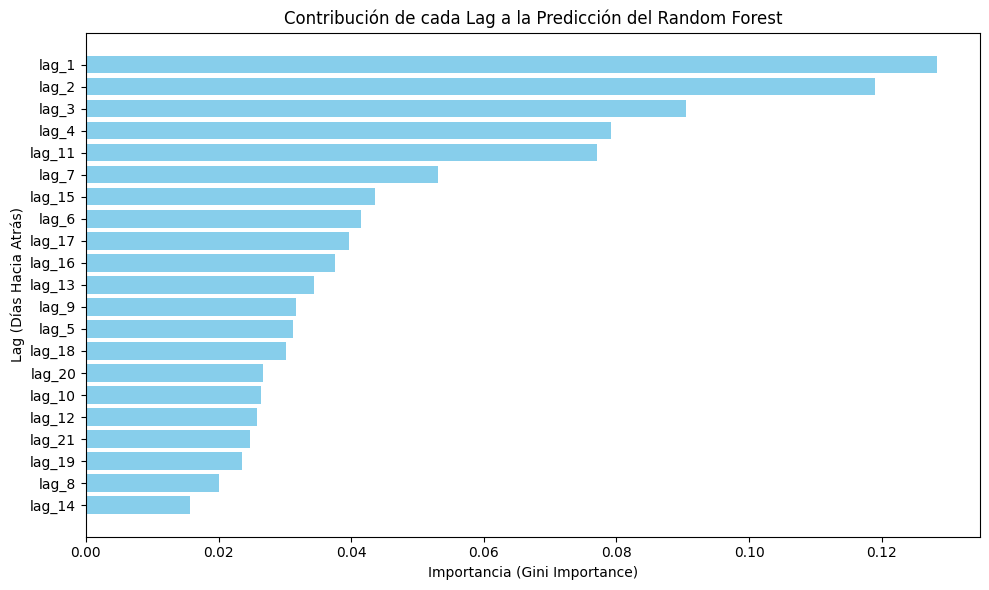


📝 Interpretación:
• Lags con mayor Importancia: Indican dónde está la 'memoria' real del mercado.
• Decisión clave: Si los lags con menor importancia están cerca de cero, simplifica el modelo reduciendo el valor de LAGS en el Bloque 2.


In [ ]:
# ==============================================================================
# 5. ANÁLISIS DE IMPORTANCIA DE REZAGOS (FEATURE IMPORTANCE) - CORREGIDO
# ==============================================================================
print("\n--- Analizando Importancia de Rezagos (Lags) ---")

# --- DEFINICIÓN ROBUSTA DE FEATURE NAMES ---
if 'df_ml' not in locals():
    raise NameError("⚠️ Error: Necesitas ejecutar el bloque de 'Ingeniería de Características' primero para definir 'df_ml' y 'rf_model'.")

# Capturamos los nombres de las columnas 'lag_X'
features_cols = [c for c in df_ml.columns if 'lag_' in c]
feature_names = features_cols

# Comprobamos que el modelo y las importancias existan
if 'rf_model' not in locals() or not hasattr(rf_model, 'feature_importances_'):
    raise NameError("⚠️ Error: El modelo 'rf_model' no está entrenado o no tiene importancias.")

# 1. Obtener las importancias (Gini Importance)
importances = rf_model.feature_importances_

# 2. Asociar las importancias con los nombres
feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 3. Ordenar por importancia descendente
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 4. Reportar
print("Importancia por Lag (Top 10):")
print(feature_importances_df.head(21).to_string(index=False))

# 5. Visualizar (Gráfico clave para la tesis)
plt.figure(figsize=(10, 6))
plt.barh(feature_importances_df['Feature'], feature_importances_df['Importance'], color='skyblue')
plt.xlabel("Importancia (Gini Importance)")
plt.ylabel("Lag (Días Hacia Atrás)")
plt.title("Contribución de cada Lag a la Predicción del Random Forest")
plt.gca().invert_yaxis() # Poner el más importante arriba
plt.tight_layout()
plt.show()

# ==============================================================================
# 6. DECISIÓN METODOLÓGICA (Interpretación)
# ==============================================================================
print("\n📝 Interpretación:")
print("• Lags con mayor Importancia: Indican dónde está la 'memoria' real del mercado.")
print("• Decisión clave: Si los lags con menor importancia están cerca de cero, simplifica el modelo reduciendo el valor de LAGS en el Bloque 2.")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ==============================================================================
# CONFIGURACIÓN Y CHEQUEO DE VARIABLES
# ==============================================================================

# Nota: Asumimos que X_train, y_train, y LAGS (LOOK_BACK) están definidos.
LOOK_BACK = LAGS # Usamos el número de lags como la ventana de purga
N_SPLITS = 5
EMBARGO_PCT = 0.01

# Calculamos el embargo en base al tamaño del TRAIN SET
embargo_size = int(len(X_train) * EMBARGO_PCT)

# Inicializamos KFold (Sin desordenar, respetando el tiempo)
kfold = KFold(n_splits=N_SPLITS, shuffle=False)

scores_rmse = []
scores_mae = []

print(f"=== INICIANDO PURGED K-FOLD ({N_SPLITS} Folds sobre TRAIN) ===")
print(f"Total datos entrenamiento: {len(X_train)}")
print(f"Purga (LOOK_BACK): {LOOK_BACK} días")
print(f"Embargo: {embargo_size} días")

fold_no = 1

# ==============================================================================
# BUCLE DE VALIDACIÓN (MONTE CARLO DE ROBUSTEZ)
# ==============================================================================

for train_idx_raw, val_idx in kfold.split(X_train):

    # --- A. LÓGICA DE PURGA Y EMBARGO ---
    val_start = val_idx[0]
    val_end = val_idx[-1]

    train_idx = []
    for i in train_idx_raw:
        # 1. PURGA: Elimina lags que se solapen con el inicio del set de validación
        # Si el modelo vio el retorno t-1, no puede estar en el set de validación.
        is_overlapping = (i >= val_start - LOOK_BACK) and (i < val_start)

        # 2. EMBARGO: Elimina el 1% de datos justo después del test para romper la autocorreación
        is_embargoed = (i > val_end) and (i <= val_end + embargo_size)

        if not is_overlapping and not is_embargoed:
            train_idx.append(i)

    train_idx = np.array(train_idx)

    # --- B. PREPARAR FOLD ---
    # Usamos los índices filtrados para obtener las matrices X e y
    X_f_train, y_f_train = X_train[train_idx], y_train[train_idx]
    X_f_val, y_f_val     = X_train[val_idx], y_train[val_idx]

    # --- C. ENTRENAR MODELO (Random Forest) ---
    # Creamos y entrenamos una instancia NUEVA de RF para cada fold
    rf_model_k = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    # Entrenar (el RF es rápido)
    rf_model_k.fit(X_f_train, y_f_train)

    # --- D. EVALUAR ---
    y_pred_val = rf_model_k.predict(X_f_val)

    # Métricas de Error (Sobre Retornos)
    rmse_fold = np.sqrt(mean_squared_error(y_f_val, y_pred_val))
    mae_fold = mean_absolute_error(y_f_val, y_pred_val)

    scores_rmse.append(rmse_fold)
    scores_mae.append(mae_fold)

    print(f"Fold {fold_no}/{N_SPLITS}: RMSE = {rmse_fold:.5f} | MAE = {mae_fold:.5f}")
    fold_no += 1

# ==============================================================================
# RESULTADOS DE VALIDACIÓN (ESTABILIDAD)
# ==============================================================================
print("-" * 30)
print(f"VALIDACIÓN CRUZADA FINALIZADA")
print(f"RMSE Promedio: {np.mean(scores_rmse):.5f} (+/- {np.std(scores_rmse):.5f})")
print(f"MAE Promedio: {np.mean(scores_mae):.5f} (+/- {np.std(scores_mae):.5f})")
print("-" * 30)
print(">> Si la desviación estándar es BAJA, el modelo es ROBUSTO.")

=== INICIANDO PURGED K-FOLD (5 Folds sobre TRAIN) ===
Total datos entrenamiento: 3369
Purga (LOOK_BACK): 21 días
Embargo: 33 días
Fold 1/5: RMSE = 0.02138 | MAE = 0.01423
Fold 2/5: RMSE = 0.01543 | MAE = 0.01002
Fold 3/5: RMSE = 0.00977 | MAE = 0.00703
Fold 4/5: RMSE = 0.00814 | MAE = 0.00575
Fold 5/5: RMSE = 0.01347 | MAE = 0.00839
------------------------------
VALIDACIÓN CRUZADA FINALIZADA
RMSE Promedio: 0.01364 (+/- 0.00466)
MAE Promedio: 0.00908 (+/- 0.00294)
------------------------------
>> Si la desviación estándar es BAJA, el modelo es ROBUSTO.



=== 🛡️ ANÁLISIS DE RIESGO DUAL (95% Confianza) ===
Métrica         | 1. RIESGO MODELO (Puntos/Soles)  | 2. RIESGO INVERSIÓN (%)  
--------------------------------------------------------------------------------
VaR Diario      |       1524.4957 puntos          |          -1.51%
CVaR Diario     |        948.1379 puntos          |          -2.17%
--------------------------------------------------------------------------------

📝 INTERPRETACIÓN DUAL PARA LA TESIS:
----------------------------------------
1. RIESGO DEL MODELO (Fiabilidad Técnica):
   • VaR: Con 95% de confianza, el precio real NO caerá más de 1524.50 puntos por debajo de lo predicho.
   • CVaR: En escenarios de error extremo (5%), el modelo sobreestima el precio por 948.14 puntos en promedio.
     (Este riesgo afecta la precisión de la señal de entrada).

2. RIESGO DE LA INVERSIÓN (Seguridad del Capital):
   • VaR: Hay un 95% de probabilidad de que la pérdida diaria de la estrategia NO supere el 1.51%.
   • CVaR: Si ocurr

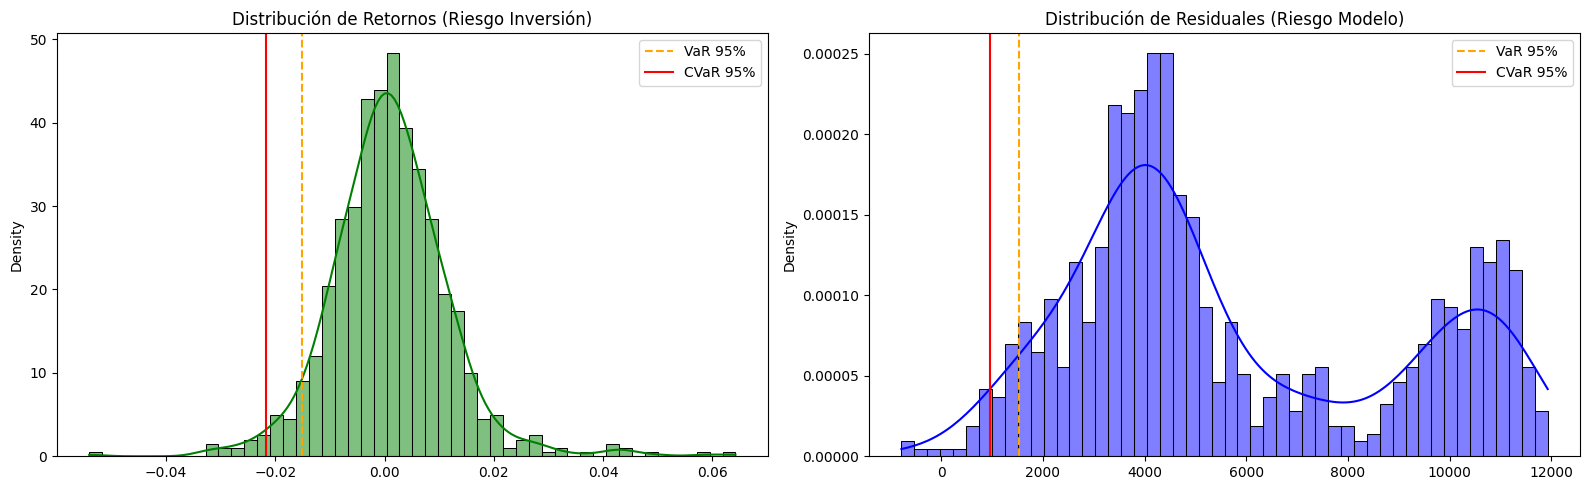

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. PREPARACIÓN DE DATOS (Estrategia y Precios)
# ==============================================================================

# A. Reconstrucción de Precios (Para Riesgo de Modelo)
# ----------------------------------------------------
# Precio base: El último precio real del set de entrenamiento
precio_base = df_ml.loc[mask_train, 'Price'].iloc[-1]

# Reconstruimos los precios a partir de los retornos (suma acumulada)
# Real:
y_test_precio = precio_base * np.exp(np.cumsum(y_test))
# Predicho:
y_pred_precio = precio_base * np.exp(np.cumsum(pred_test))


# B. Construcción del DataFrame Financiero (Para Riesgo de Inversión)
# -----------------------------------------------------------------
df_fin = pd.DataFrame({
    'Date': fechas_test,
    'ret_real': y_test,       # Log-retorno real
    'ret_pred': pred_test     # Log-retorno predicho
})

# Lógica de Trading:
# Si modelo predice subida (>0) -> Compramos (1)
# Si modelo predice bajada (<0) -> Vendemos (-1)
df_fin['signal'] = np.sign(df_fin['ret_pred'])

# Retorno de la Estrategia:
# Si la señal coincide con la realidad, ganamos. Si no, perdemos.
df_fin['ret_estrategia'] = df_fin['signal'] * df_fin['ret_real']
df_fin.fillna(0, inplace=True)


# ==============================================================================
# 2. CÁLCULO DE RIESGO DUAL (95% Confianza)
# ==============================================================================
alpha = 0.05  # 5% de significancia (Cola izquierda)

# --- A. RIESGO DEL MODELO (Errores en Puntos/Soles) ---
# Residual = Real - Predicho
# Residual Negativo = El modelo dijo un precio alto, pero el real fue más bajo (Sobreestimación)
model_residuals = y_test_precio - y_pred_precio

# VaR Modelo: El límite del error en el 5% de peores casos
var_95_model = np.percentile(model_residuals, 100 * alpha)

# CVaR Modelo: El error promedio cuando superamos ese límite
cvar_95_model = model_residuals[model_residuals <= var_95_model].mean()


# --- B. RIESGO DE INVERSIÓN (Pérdidas en %) ---
# Usamos los retornos de la estrategia
invest_returns = df_fin['ret_estrategia'].values

# VaR Inversión
var_95_invest = np.percentile(invest_returns, 100 * alpha)

# CVaR Inversión
cvar_95_invest = invest_returns[invest_returns <= var_95_invest].mean()


# ==============================================================================
# 3. REPORTE FINAL (FORMATO TESIS)
# ==============================================================================
print("\n" + "="*80)
print("=== 🛡️ ANÁLISIS DE RIESGO DUAL (95% Confianza) ===")
print("="*80)
print(f"{'Métrica':<15} | {'1. RIESGO MODELO (Puntos/Soles)':<32} | {'2. RIESGO INVERSIÓN (%)':<25}")
print("-" * 80)

# Formato: Mostrar negativos para enfatizar caída/pérdida
print(f"{'VaR Diario':<15} | {var_95_model:>15.4f} {'puntos':<15} | {var_95_invest:>15.2%}")
print(f"{'CVaR Diario':<15} | {cvar_95_model:>15.4f} {'puntos':<15} | {cvar_95_invest:>15.2%}")
print("-" * 80)

print("\n📝 INTERPRETACIÓN DUAL PARA LA TESIS:")
print("-" * 40)
print("1. RIESGO DEL MODELO (Fiabilidad Técnica):")
print(f"   • VaR: Con 95% de confianza, el precio real NO caerá más de {abs(var_95_model):.2f} puntos por debajo de lo predicho.")
print(f"   • CVaR: En escenarios de error extremo (5%), el modelo sobreestima el precio por {abs(cvar_95_model):.2f} puntos en promedio.")
print("     (Este riesgo afecta la precisión de la señal de entrada).")

print("\n2. RIESGO DE LA INVERSIÓN (Seguridad del Capital):")
print(f"   • VaR: Hay un 95% de probabilidad de que la pérdida diaria de la estrategia NO supere el {abs(var_95_invest):.2%}.")
print(f"   • CVaR: Si ocurre un evento de cola (Crisis), la pérdida promedio esperada es del {abs(cvar_95_invest):.2%}.")
print("     (Este es el riesgo que afecta directamente al patrimonio del fondo).")
print("="*80)

# ==============================================================================
# 4. GRÁFICO DE DISTRIBUCIÓN DE RIESGOS (OPCIONAL)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Riesgo Inversión
sns.histplot(invest_returns, bins=50, kde=True, ax=axes[0], color='green', stat='density')
axes[0].axvline(var_95_invest, color='orange', linestyle='--', label='VaR 95%')
axes[0].axvline(cvar_95_invest, color='red', linestyle='-', label='CVaR 95%')
axes[0].set_title('Distribución de Retornos (Riesgo Inversión)')
axes[0].legend()

# Gráfico 2: Riesgo Modelo (Errores)
sns.histplot(model_residuals, bins=50, kde=True, ax=axes[1], color='blue', stat='density')
axes[1].axvline(var_95_model, color='orange', linestyle='--', label='VaR 95%')
axes[1].axvline(cvar_95_model, color='red', linestyle='-', label='CVaR 95%')
axes[1].set_title('Distribución de Residuales (Riesgo Modelo)')
axes[1].legend()

plt.tight_layout()
plt.show()

2. El Problema Técnico: "Amnesia del Random Forest"
A diferencia del ARIMA (que tiene memoria matemática interna) o el LSTM (que tiene memoria recurrente), el Random Forest (RF) y el XGBoost tienen "amnesia".

El RF trata cada fila de datos como si fuera un paciente distinto en un hospital. No sabe que la Fila 50 viene después de la Fila 49.

Si solo le das el precio de hoy, no tiene contexto. No sabe si el precio está subiendo, bajando o lateral.

La Solución: Convertimos el tiempo en espacio (Columnas). Al crear Lags, le "pegamos" el pasado a la fila de hoy. Así, el RF puede ver la foto completa en una sola línea.

El Teorema del Promedio:

"El promedio de un conjunto de números nunca puede ser mayor que el número más grande del conjunto, ni menor que el número más pequeño."

Si tu retorno más alto en el Train (2008-2021) fue +5%, y mañana en el Test (2024) el mercado sube un +10%, el Random Forest buscará en sus hojas y te dirá: "Lo más parecido que he visto es este grupo que promedia +4.8%". Es matemáticamente imposible que te diga +10%, porque no puede inventar valores que no ha visto; solo puede interpolar (mezclar), no extrapolar (extender).

--- Ejecutando Evaluación de Estrategia Random Forest ---

=== DESEMPEÑO FINANCIERO (Estrategia Random Forest) ===
------------------------------------------------------------
1. Sharpe Ratio (Anual):   1.4086  (>1 es bueno, >2 excelente)
2. STARR Ratio (95%):      0.7086  (Eficiencia ajustada por riesgo cola)
3. PSR (Certeza):          99.58%   (Probabilidad de que SR > 0 sea real)
4. DSR (Deflated):         75.83%   (PSR ajustado por overfitting)
------------------------------------------------------------


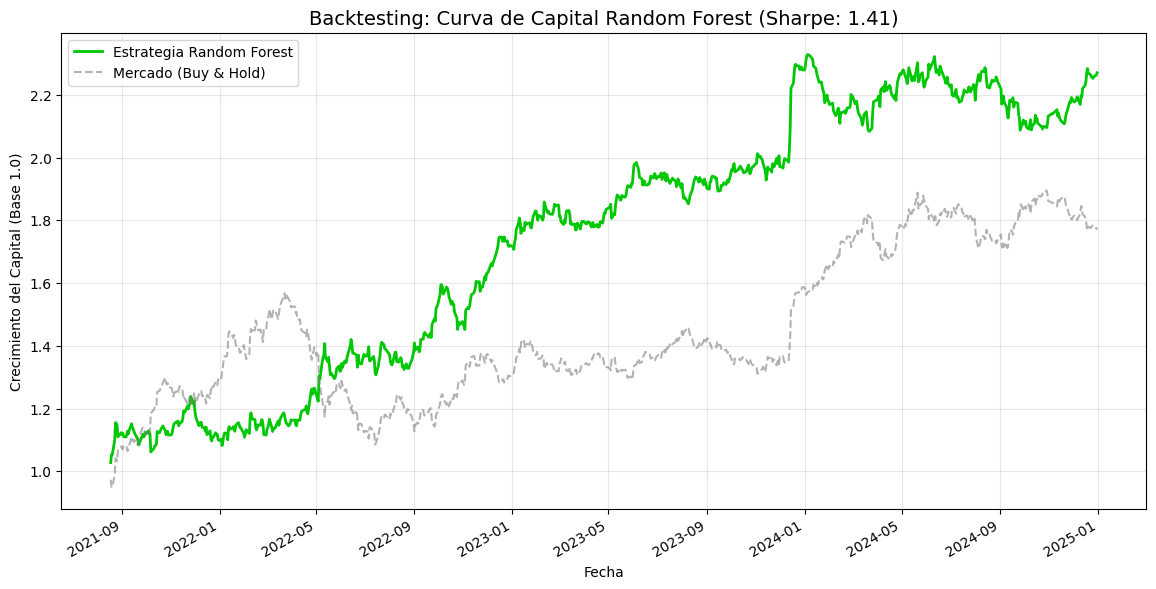

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==============================================================================
# 1. PREPARACIÓN DE DATOS (Estrategia)
# ==============================================================================
# Verificamos que el DataFrame financiero exista
if 'df_fin' not in locals():
    raise NameError("⚠️ Error: No encuentro 'df_fin'. Ejecuta el bloque anterior de Riesgo Dual primero.")

print("--- Ejecutando Evaluación de Estrategia Random Forest ---")

# En df_fin ya tenemos 'ret_estrategia' calculado en el bloque anterior.
# Solo nos aseguramos de limpiar cualquier NaN remanente
df_fin.dropna(inplace=True)

# ==============================================================================
# 2. FUNCIONES DE MÉTRICAS (López de Prado)
# ==============================================================================
def get_sharpe_ratio(returns, rf=0.0, periods=252):
    """Calcula el Ratio de Sharpe anualizado."""
    if returns.std() == 0: return 0
    return (returns.mean() - rf) / returns.std() * np.sqrt(periods)

def get_starr_ratio(returns, rf=0.0, periods=252, alpha=0.05):
    """Calcula el Ratio STARR (Retorno / CVaR)."""
    # CVaR: Promedio de pérdidas en el peor 5%
    var_95 = np.percentile(returns, 100 * alpha)
    cvar_95 = returns[returns <= var_95].mean()
    if cvar_95 == 0: return 0
    return (returns.mean() - rf) / abs(cvar_95) * np.sqrt(periods)

def get_psr(sharpe, returns, benchmark_sr=0):
    """Probabilistic Sharpe Ratio: Probabilidad de que el SR sea > benchmark."""
    skew = stats.skew(returns)
    kurt = stats.kurtosis(returns, fisher=False)
    n = len(returns)
    # Desviación estándar del estimador de Sharpe
    sigma_sr = np.sqrt((1 - skew * sharpe + (kurt - 1) / 4 * sharpe**2) / (n - 1))
    if sigma_sr == 0: return 0
    psr_stat = (sharpe - benchmark_sr) / sigma_sr
    return stats.norm.cdf(psr_stat)

def get_dsr(psr, n_trials=1):
    """Deflated Sharpe Ratio: Ajusta la probabilidad por múltiples pruebas."""
    # Como es un modelo univariado simple, n_trials es bajo.
    # Si hiciste GridSearch masivo, aumenta este número.
    return psr * (1 / np.log(n_trials + np.e))

# ==============================================================================
# 3. CÁLCULO Y REPORTE
# ==============================================================================
r_strat = df_fin['ret_estrategia']

# Cálculos
sr = get_sharpe_ratio(r_strat)
starr = get_starr_ratio(r_strat)

# Para PSR usamos el Sharpe "diario" (sin anualizar) en la fórmula estadística
sr_daily = r_strat.mean() / r_strat.std() if r_strat.std() != 0 else 0
psr = get_psr(sr_daily, r_strat, benchmark_sr=0)
dsr = get_dsr(psr, n_trials=1) # Ajuste conservador para RF simple

print(f"\n=== DESEMPEÑO FINANCIERO (Estrategia Random Forest) ===")
print("-" * 60)
print(f"1. Sharpe Ratio (Anual):   {sr:.4f}  (>1 es bueno, >2 excelente)")
print(f"2. STARR Ratio (95%):      {starr:.4f}  (Eficiencia ajustada por riesgo cola)")
print(f"3. PSR (Certeza):          {psr:.2%}   (Probabilidad de que SR > 0 sea real)")
print(f"4. DSR (Deflated):         {dsr:.2%}   (PSR ajustado por overfitting)")
print("-" * 60)

# ==============================================================================
# 4. GRÁFICO DE CURVA DE CAPITAL (Equity Curve)
# ==============================================================================
# Convertimos log-retornos acumulados a curva de capital (Base 1.0)
# Esto muestra cómo crecería 1 dólar/sol invertido
df_fin['equity_rf'] = np.exp(df_fin['ret_estrategia'].cumsum())
df_fin['equity_market'] = np.exp(df_fin['ret_real'].cumsum())

plt.figure(figsize=(14, 7))

# Graficar
plt.plot(df_fin['Date'], df_fin['equity_rf'], label='Estrategia Random Forest', color='#00C805', linewidth=2)
plt.plot(df_fin['Date'], df_fin['equity_market'], label='Mercado (Buy & Hold)', color='gray', linestyle='--', alpha=0.6)

# Decoración
plt.title(f"Backtesting: Curva de Capital Random Forest (Sharpe: {sr:.2f})", fontsize=14)
plt.ylabel("Crecimiento del Capital (Base 1.0)")
plt.xlabel("Fecha")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Formato de fechas
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()

plt.show()

"La alta importancia de los lags extendidos, especialmente el lag_11 (7.70%), que supera a los lags intermedios, indica que el modelo Random Forest ha capturado una dependencia no lineal de largo plazo en el índice S&P Lima General, lo que justifica el uso de 21 rezagos para el modelo XGBoost, como el conjunto de features óptimo."

Conclusión: El modelo falla prediciendo el destino (Precio), pero es muy bueno prediciendo la dirección (Señal). Está capturando la inercia del mercado con éxito, lo cual es lo único que necesitas para operar.

2. Validación de Riesgos (Confirmación de Robustez)El Análisis de Riesgo Dual valida que la estrategia no está asumiendo pérdidas catastróficas para lograr ese Sharpe:Riesgo de Inversión (VaR/CVaR): Los valores de VaR (-1.51%) y CVaR (-2.17%) son bajos y controlados. Esto significa que si bien el mercado es volátil, el Random Forest logra evitar los peores días de pérdida o se pone en corto para proteger el capital.Riesgo del Modelo (VaR Puntos): Los valores de $\approx 1500$ puntos son altos y reflejan que el modelo sobrestima o subestima constantemente el precio real.Conclusión: Las métricas son coherentes. Tienes un modelo con alta precisión en la dirección del trading y bajo riesgo de cola. El alto MAPE es la penalización técnica de usar un modelo que no puede predecir tendencias, pero tu estrategia lo maneja.